# 05 - Results Analysis

Final performance evaluation of the DenseNet-Attention model on the held-out test set.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import get_dataloaders
from src.models import get_model
from src.evaluate import evaluate_model, plot_confusion_matrix
from src.utils import set_seed, get_device, load_config

plt.rcParams["figure.dpi"] = 130
sns.set_style("whitegrid")

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]

print(f"Device: {device}")

Device: cuda


In [2]:
set_seed(SEED)

dataloaders = get_dataloaders(
    DATA_ROOT,
    augmentation="standard",
    image_size=config["data"]["image_size"],
    batch_size=32,
    num_workers=0,
    seed=SEED
)

model = get_model("densenet_attention", pretrained=True, use_attention=True)
checkpoint_path = "../results/checkpoints/densenet_attention_best.pt"

model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
model = model.to(device)
model.eval()

print("✅ Best DenseNet-Attention model loaded successfully.")

✅ Best DenseNet-Attention model loaded successfully.


In [3]:
test_results = evaluate_model(model, dataloaders["test"], device)
m = test_results["metrics"]

print("=== FINAL TEST RESULTS (threshold = 0.5) ===")
print(f"AUROC          : {m['auroc']:.4f}")
print(f"F1 (macro)     : {m['f1_macro']:.4f}")
print(f"Accuracy       : {m['accuracy']:.4f}")
print(f"Sensitivity    : {m['sensitivity']:.4f}")
print(f"Specificity    : {m['specificity']:.4f}")
print(f"NPV            : {m['npv']:.4f}")
print(f"Confusion (TP/FP/TN/FN): {m['tp']}/{m['fp']}/{m['tn']}/{m['fn']}")

# Threshold-independent operating points for the clinical write-up
ta = test_results["threshold_analysis"]
print("\n=== FINAL TEST RESULTS (Youden-optimal threshold) ===")
print(f"Threshold      : {ta['youden_threshold']:.4f}")
print(f"Sensitivity    : {ta['youden_sensitivity']:.4f}")
print(f"Specificity    : {ta['youden_specificity']:.4f}")

# Keep these around for later cells that do FP/FN analysis
y_true = test_results["y_true"]
y_proba = test_results["y_proba"]

=== FINAL TEST RESULTS (threshold = 0.5) ===
AUROC          : 0.9860
F1 (macro)     : 0.8699
Accuracy       : 0.8862
Sensitivity    : 0.9923
Specificity    : 0.7094
NPV            : 0.9822
Confusion (TP/FP/TN/FN): 387/68/166/3

=== FINAL TEST RESULTS (Youden-optimal threshold) ===
Threshold      : 0.8837
Sensitivity    : 0.9513
Specificity    : 0.9530


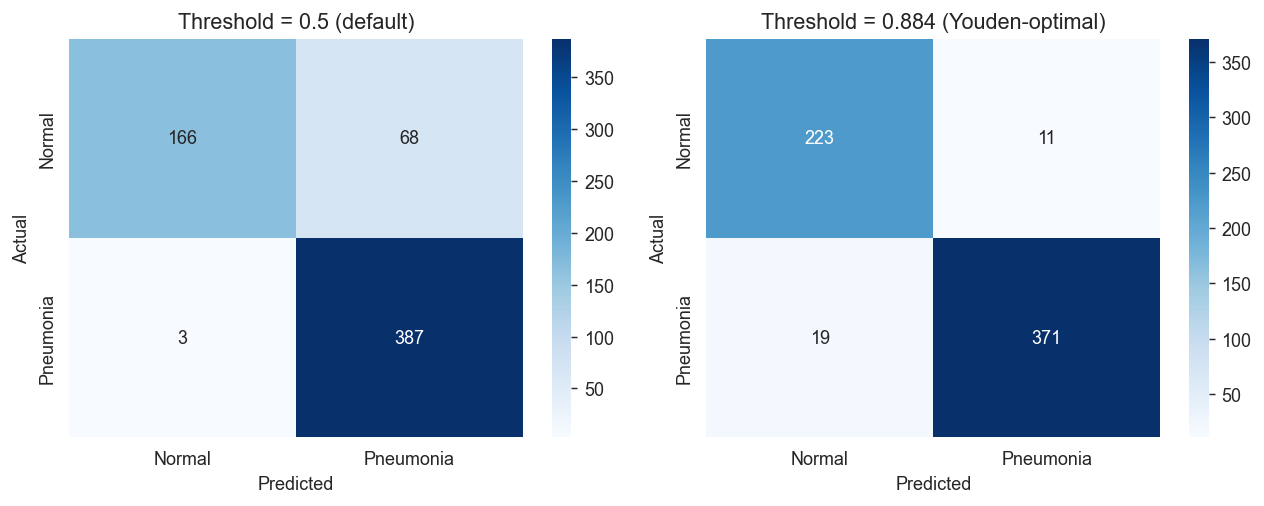

In [4]:
youden_thr = test_results["threshold_analysis"]["youden_threshold"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(y_true, y_proba, threshold=0.5,
                      title=f"Threshold = 0.5 (default)", ax=axes[0])
plot_confusion_matrix(y_true, y_proba, threshold=youden_thr,
                      title=f"Threshold = {youden_thr:.3f} (Youden-optimal)", ax=axes[1])
plt.tight_layout()
plt.savefig("../results/confusion_default_vs_youden.png", bbox_inches="tight")
plt.show()